# Predicting Customer Lifetime Value in E-Commerce

**Author:** Maurice Rueegg  
**Course:** Fundamentals of Python Applications in Data Science (ZHAW, 8th Semester)  
**Focus:** E — Supervised Learning: Regression and XAI  

---

## Section 0 — Data Generation

This section generates the raw dataset from the provided code. The dataset is saved to `01_data/topic_E2_customer_lifetime_value_raw.csv`. The random seed `808` ensures full reproducibility.

> **Note:** Run this section first. All subsequent sections load from the saved CSV.

In [1]:
import os
import pandas as pd
import numpy as np

np.random.seed(808)

n = 1100

customer_tenure_months = np.random.randint(1, 61, n)
purchase_count_last_12m = np.random.poisson(lam=8, size=n)
purchase_count_last_12m = np.clip(purchase_count_last_12m, 0, 45)

avg_order_value_chf = np.round(np.random.normal(85, 35, n), 2)
avg_order_value_chf = np.clip(avg_order_value_chf, 10, 400)

return_rate = np.round(np.random.beta(2, 8, n), 3)
website_visits_last_3m = np.random.poisson(lam=24, size=n)
email_click_rate = np.round(np.random.beta(2.5, 4.5, n), 3)

customer_segment = np.random.choice(
    ["new", "occasional", "loyal", "premium"],
    size=n,
    p=[0.2, 0.36, 0.3, 0.14]
)

preferred_device = np.random.choice(
    ["mobile", "desktop", "tablet"],
    size=n,
    p=[0.58, 0.34, 0.08]
)

support_tickets_last_12m = np.random.poisson(lam=1.8, size=n)
support_tickets_last_12m = np.clip(support_tickets_last_12m, 0, 12)

discount_usage_rate = np.round(np.random.beta(3, 4, n), 3)

# CLV generating mechanism
base_value = 40
tenure_effect          = customer_tenure_months * 9
purchase_effect        = purchase_count_last_12m * 42
order_value_effect     = avg_order_value_chf * 5.2
visit_effect           = website_visits_last_3m * 1.4
click_effect           = email_click_rate * 220
return_penalty         = -return_rate * 520
support_penalty        = -support_tickets_last_12m * 24
discount_penalty       = -discount_usage_rate * 180

segment_effect = np.where(customer_segment == "premium", 420,
    np.where(customer_segment == "loyal", 180,
        np.where(customer_segment == "occasional", 40, -60)))

device_effect = np.where(preferred_device == "desktop", 20,
    np.where(preferred_device == "tablet", -10, 0))

# Non-linear / interaction effects
premium_order_bonus  = np.where(customer_segment == "premium", avg_order_value_chf * 1.4, 0)
loyal_tenure_bonus   = np.where(customer_segment == "loyal",   customer_tenure_months * 2.5, 0)
high_discount_penalty = np.where(discount_usage_rate > 0.75, -120, 0)

noise = np.random.normal(0, 120, n)

customer_lifetime_value_chf = (
    base_value + tenure_effect + purchase_effect + order_value_effect
    + visit_effect + click_effect + return_penalty + support_penalty
    + discount_penalty + segment_effect + device_effect
    + premium_order_bonus + loyal_tenure_bonus + high_discount_penalty
    + noise
)
customer_lifetime_value_chf = np.round(np.clip(customer_lifetime_value_chf, 20, None), 2)

df_raw = pd.DataFrame({
    "customer_tenure_months":    customer_tenure_months,
    "purchase_count_last_12m":   purchase_count_last_12m,
    "avg_order_value_chf":       avg_order_value_chf,
    "return_rate":               return_rate,
    "website_visits_last_3m":    website_visits_last_3m,
    "email_click_rate":          email_click_rate,
    "customer_segment":          customer_segment,
    "preferred_device":          preferred_device,
    "support_tickets_last_12m":  support_tickets_last_12m,
    "discount_usage_rate":       discount_usage_rate,
    "customer_lifetime_value_chf": customer_lifetime_value_chf,
})

# Save raw dataset
DATA_DIR = "01_data"
CSV_PATH = os.path.join(DATA_DIR, "topic_E2_customer_lifetime_value_raw.csv")
os.makedirs(DATA_DIR, exist_ok=True)
df_raw.to_csv(CSV_PATH, index=False)

print(f"Dataset saved to: {CSV_PATH}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Dataset saved to: 01_data/topic_E2_customer_lifetime_value_raw.csv
Shape: (1100, 11)


,customer_tenure_months,purchase_count_last_12m,avg_order_value_chf,return_rate,website_visits_last_3m,email_click_rate,customer_segment,preferred_device,support_tickets_last_12m,discount_usage_rate,customer_lifetime_value_chf
0,15,4,27.60,0.254,20,0.369,loyal,desktop,0,0.734,392.51
1,54,4,80.07,0.246,29,0.526,premium,desktop,1,0.763,1375.01
2,39,6,96.03,0.400,25,0.275,new,mobile,1,0.672,756.76
3,54,3,11.37,0.260,22,0.551,premium,mobile,3,0.452,779.73
4,58,9,137.04,0.028,23,0.122,occasional,tablet,2,0.527,1590.10


---

## Section 1 — Problem Framing

### What is Customer Lifetime Value?

**Customer Lifetime Value (CLV)** is the total revenue a business can expect from a single customer over their entire relationship. It is a core metric in e-commerce because:

- It identifies which customers are most valuable and worth retaining
- It guides marketing spend decisions (customer acquisition cost vs. expected value)
- It enables personalised retention strategies
- It allows customer segmentation for targeted offers

### Task Definition

This is a **supervised regression** problem:

- **Input (X):** 10 behavioural and demographic customer attributes
- **Target (y):** `customer_lifetime_value_chf` — a continuous value in Swiss Francs (CHF)
- **Goal:** Build models that predict CLV accurately and explain what drives each prediction

### Objectives

1. **Feature Engineering:** Extract meaningful signals from raw behavioural data
2. **Modelling:** Train three regression models with different assumptions:
   - Linear Regression (linear baseline)
   - Random Forest (non-linear ensemble)
   - XGBoost (gradient boosted trees)
3. **Evaluation:** Compare models using RMSE, MAE, and R² with 5-fold cross-validation
4. **Explainability (XAI):** Use SHAP values to explain global and local feature effects

### Why Three Models?

The CLV generating formula contains both linear components and non-linear interaction effects (e.g., premium customers receive an additional bonus proportional to their order value). Comparing a linear model against two tree-based models tests whether capturing these interactions improves predictive accuracy — and SHAP makes the differences interpretable.

### Success Criteria

| Criterion | Target |
|-----------|--------|
| Model accuracy | R² > 0.85 for best model |
| RMSE | < 200 CHF (close to noise floor of ~120 CHF) |
| SHAP analysis | Top SHAP features match known CLV drivers |
| Reproducibility | Notebook runs top-to-bottom without errors |

---

## Section 2 — Data Understanding

This section explores the dataset's structure, distributions, and relationships. Understanding the data before modelling prevents surprises and guides feature engineering decisions.

In [2]:
# Imports for EDA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load the raw dataset
df = pd.read_csv("01_data/topic_E2_customer_lifetime_value_raw.csv")

# ── Basic info ──
print('=== Dataset Info ===')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
Shape: 1100 rows × 11 columns

=== Data Types ===
customer_tenure_months           int64
purchase_count_last_12m          int64
avg_order_value_chf            float64
return_rate                    float64
website_visits_last_3m           int64
email_click_rate               float64
customer_segment                   str
preferred_device                   str
support_tickets_last_12m         int64
discount_usage_rate            float64
customer_lifetime_value_chf    float64
dtype: object

=== Missing Values ===
customer_tenure_months         0
purchase_count_last_12m        0
avg_order_value_chf            0
return_rate                    0
website_visits_last_3m         0
email_click_rate               0
customer_segment               0
preferred_device               0
support_tickets_last_12m       0
discount_usage_rate            0
customer_lifetime_value_chf    0
dtype: int64


In [3]:
# Descriptive statistics
print('=== Descriptive Statistics (numeric features) ===')
df.describe().round(2)

=== Descriptive Statistics (numeric features) ===


,customer_tenure_months,purchase_count_last_12m,avg_order_value_chf,return_rate,website_visits_last_3m,email_click_rate,support_tickets_last_12m,discount_usage_rate,customer_lifetime_value_chf
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,31.14,8.00,85.25,0.20,24.26,0.36,1.76,0.43,1145.34
std,17.80,2.78,34.47,0.12,5.19,0.17,1.34,0.17,381.95
min,1.00,0.00,10.00,0.00,10.00,0.02,0.00,0.02,216.13
25%,16.00,6.00,60.46,0.11,20.00,0.22,1.00,0.30,896.74
50%,32.00,8.00,84.75,0.18,24.00,0.34,2.00,0.42,1124.81
75%,47.00,10.00,109.84,0.27,28.00,0.48,3.00,0.55,1386.08
max,60.00,18.00,207.89,0.68,42.00,0.87,9.00,0.92,2420.52


### 2.1 Target Variable: `customer_lifetime_value_chf`

Before exploring features, we examine the target variable distribution. Skewed targets can affect model assumptions (especially for Linear Regression) and may indicate the need for log-transformation.

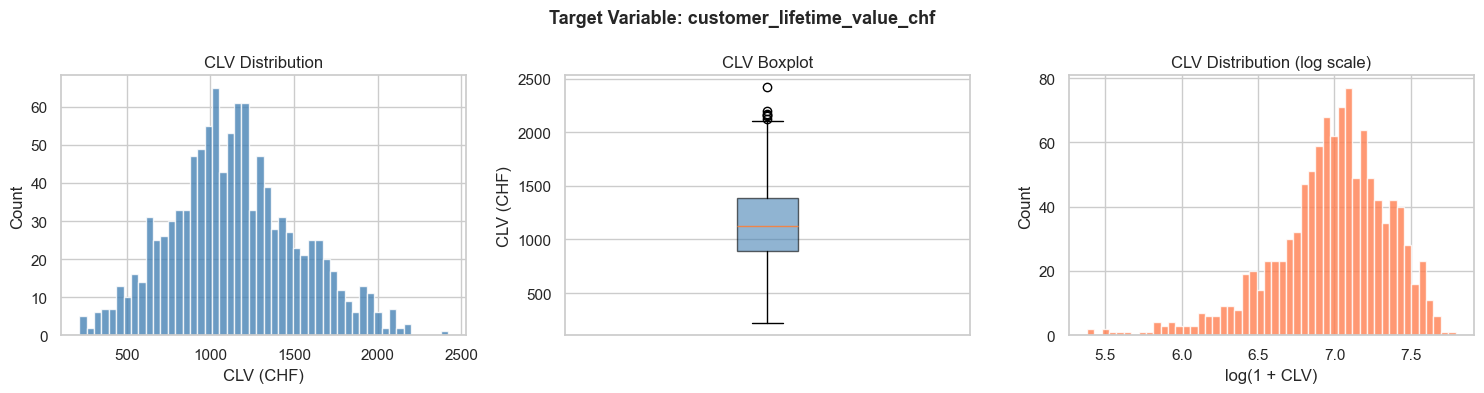

Mean CLV:    1145.34 CHF
Median CLV:  1124.81 CHF
Std CLV:     381.95 CHF
Min CLV:     216.13 CHF
Max CLV:     2420.52 CHF
Skewness:    0.250


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram with KDE
axes[0].hist(df['customer_lifetime_value_chf'], bins=50, edgecolor='white', color='steelblue', alpha=0.8)
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV (CHF)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['customer_lifetime_value_chf'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('CLV Boxplot')
axes[1].set_ylabel('CLV (CHF)')
axes[1].set_xticks([])

# Log-scale distribution
log_clv = np.log1p(df['customer_lifetime_value_chf'])
axes[2].hist(log_clv, bins=50, edgecolor='white', color='coral', alpha=0.8)
axes[2].set_title('CLV Distribution (log scale)')
axes[2].set_xlabel('log(1 + CLV)')
axes[2].set_ylabel('Count')

plt.suptitle('Target Variable: customer_lifetime_value_chf', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean CLV:    {df["customer_lifetime_value_chf"].mean():.2f} CHF')
print(f'Median CLV:  {df["customer_lifetime_value_chf"].median():.2f} CHF')
print(f'Std CLV:     {df["customer_lifetime_value_chf"].std():.2f} CHF')
print(f'Min CLV:     {df["customer_lifetime_value_chf"].min():.2f} CHF')
print(f'Max CLV:     {df["customer_lifetime_value_chf"].max():.2f} CHF')
print(f'Skewness:    {df["customer_lifetime_value_chf"].skew():.3f}')

### 2.2 Numeric Feature Distributions

Each numeric feature is examined for its distribution shape. Features with skewed distributions are noted — they may benefit from transformation or special treatment.

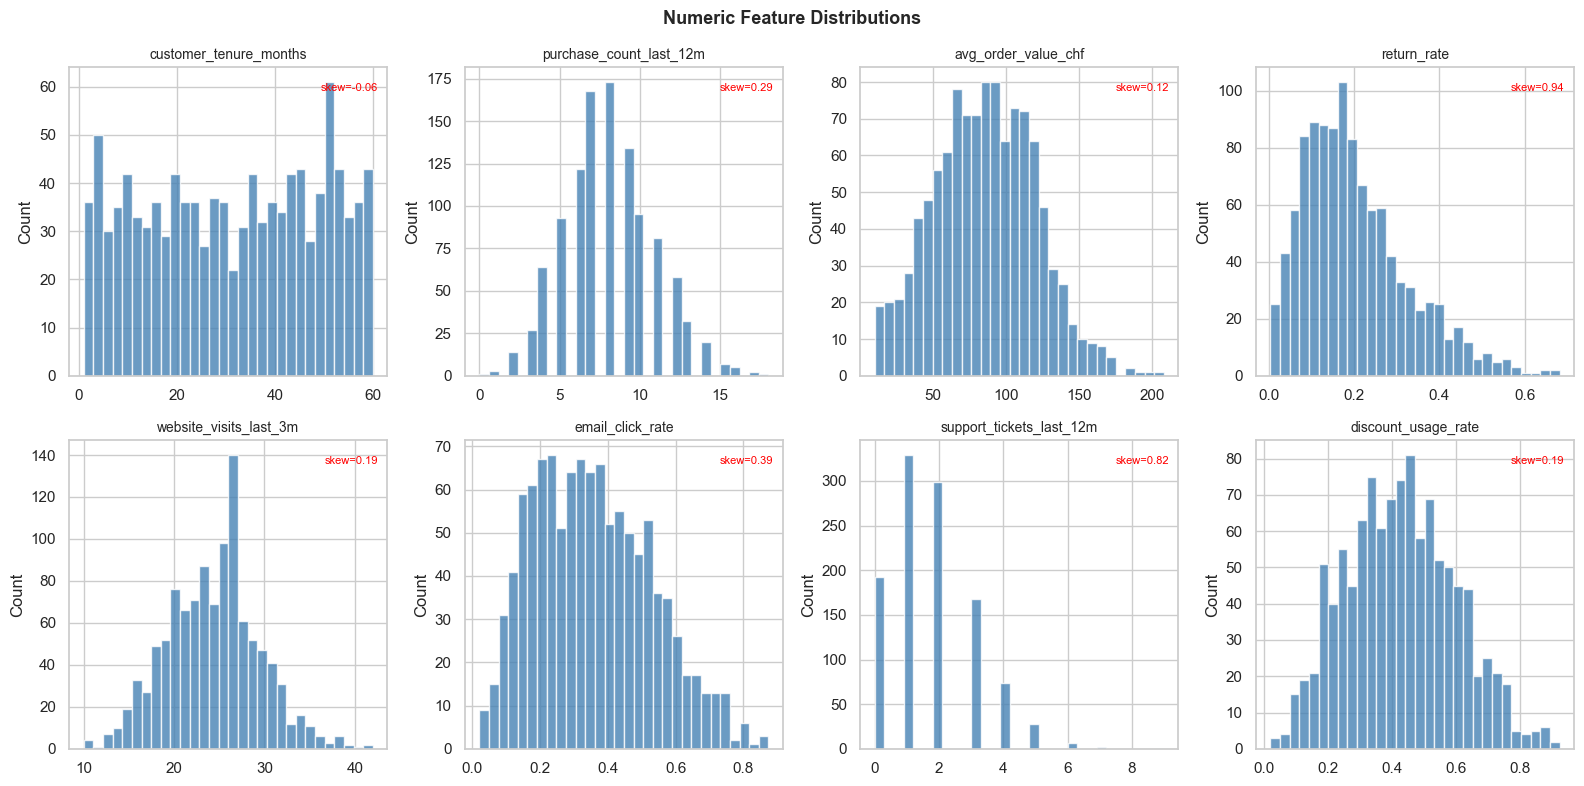

In [5]:
numeric_cols = [
    'customer_tenure_months', 'purchase_count_last_12m', 'avg_order_value_chf',
    'return_rate', 'website_visits_last_3m', 'email_click_rate',
    'support_tickets_last_12m', 'discount_usage_rate'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', alpha=0.8, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Count')
    skew = df[col].skew()
    axes[i].text(0.97, 0.95, f'skew={skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=8, color='red')

plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Categorical Feature Distributions

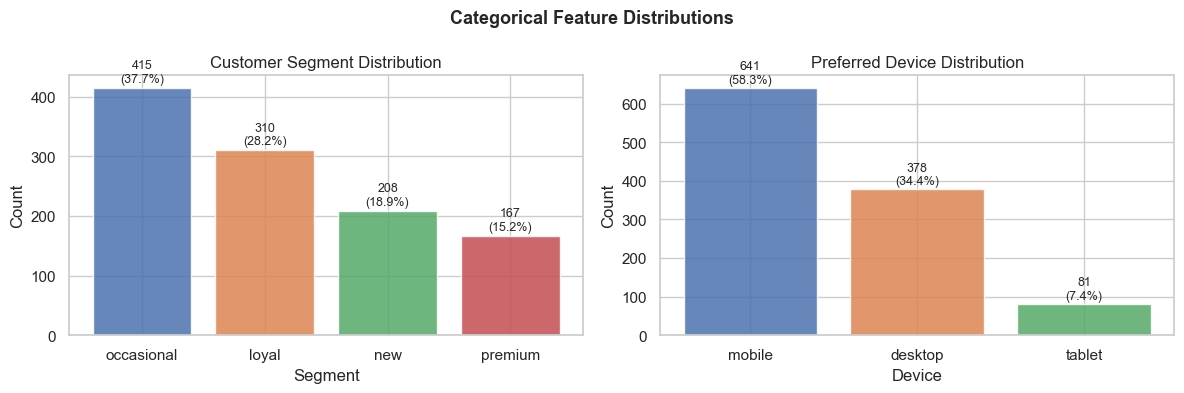

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# customer_segment
segment_counts = df['customer_segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'], alpha=0.85)
axes[0].set_title('Customer Segment Distribution')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(segment_counts.items()):
    axes[0].text(i, val + 5, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# preferred_device
device_counts = df['preferred_device'].value_counts()
axes[1].bar(device_counts.index, device_counts.values, color=['#4C72B0','#DD8452','#55A868'], alpha=0.85)
axes[1].set_title('Preferred Device Distribution')
axes[1].set_xlabel('Device')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(device_counts.items()):
    axes[1].text(i, val + 5, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 CLV by Segment and Device

Boxplots show how CLV varies across categorical feature levels. Large differences between groups suggest these features are strong predictors.

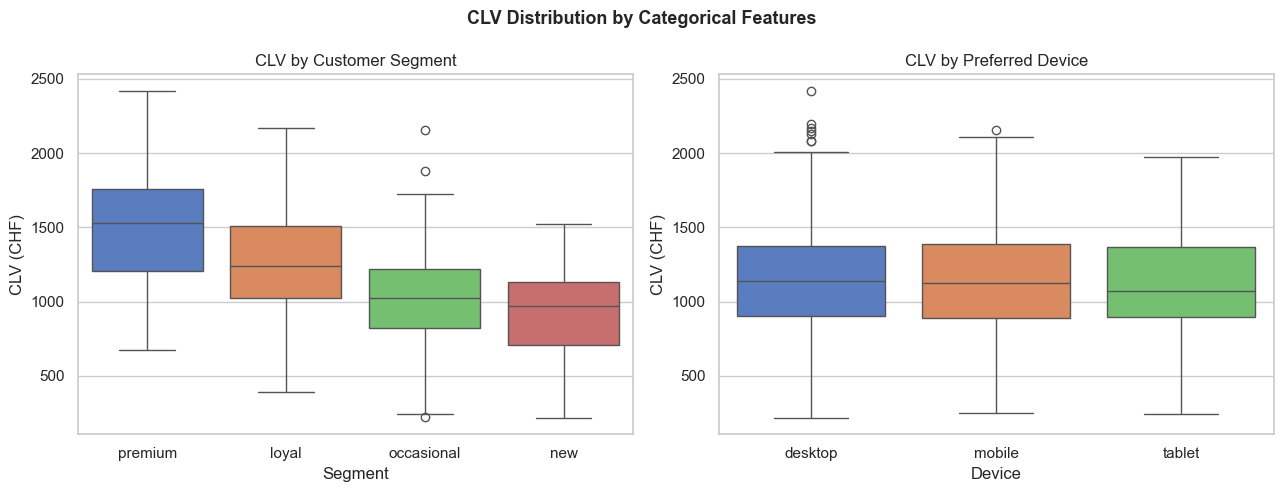

Median CLV by segment:
customer_segment
premium       1532.47
loyal         1238.16
occasional    1021.63
new            968.26
Name: customer_lifetime_value_chf, dtype: float64

Median CLV by device:
preferred_device
desktop    1140.03
mobile     1124.43
tablet     1073.15
Name: customer_lifetime_value_chf, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CLV by segment — ordered by median descending
segment_order = (
    df.groupby('customer_segment')['customer_lifetime_value_chf']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(
    data=df, x='customer_segment', y='customer_lifetime_value_chf',
    order=segment_order, ax=axes[0], palette='muted'
)
axes[0].set_title('CLV by Customer Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('CLV (CHF)')

# CLV by device — ordered by median descending
device_order = (
    df.groupby('preferred_device')['customer_lifetime_value_chf']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(
    data=df, x='preferred_device', y='customer_lifetime_value_chf',
    order=device_order, ax=axes[1], palette='muted'
)
axes[1].set_title('CLV by Preferred Device')
axes[1].set_xlabel('Device')
axes[1].set_ylabel('CLV (CHF)')

plt.suptitle('CLV Distribution by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median CLV by segment:')
print(df.groupby('customer_segment')['customer_lifetime_value_chf'].median().sort_values(ascending=False).round(2))
print()
print('Median CLV by device:')
print(df.groupby('preferred_device')['customer_lifetime_value_chf'].median().sort_values(ascending=False).round(2))

### 2.5 Correlation Analysis

The Pearson correlation matrix shows linear relationships between numeric features and the target. High correlation with CLV indicates a feature is a strong linear predictor. High inter-feature correlations may indicate multicollinearity.

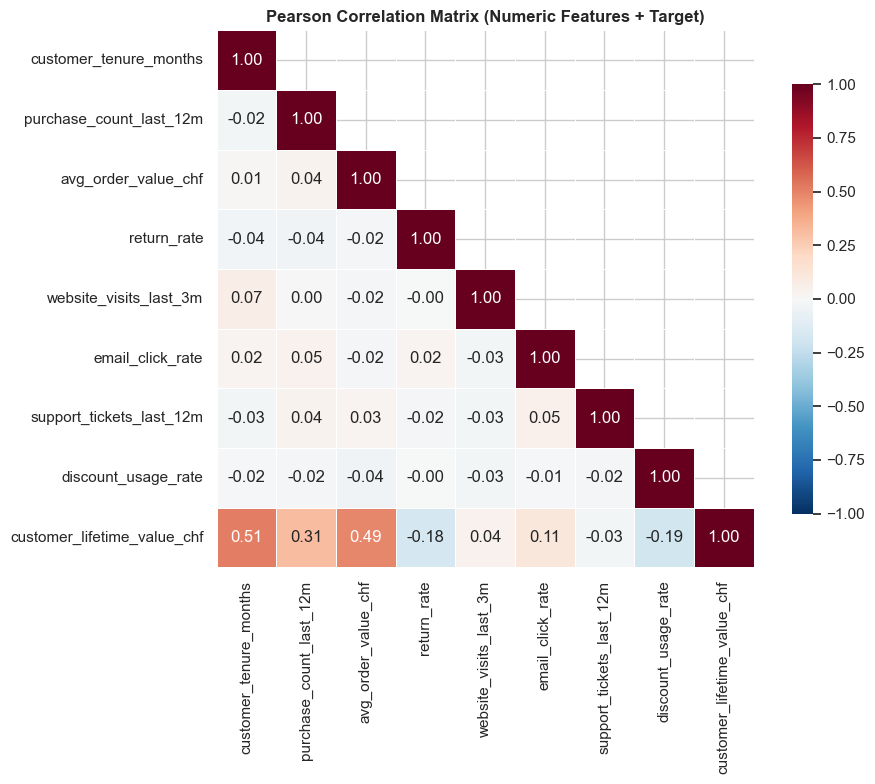

Correlation with CLV (sorted by absolute value):
customer_tenure_months      0.508
avg_order_value_chf         0.487
purchase_count_last_12m     0.307
discount_usage_rate         0.194
return_rate                 0.179
email_click_rate            0.113
website_visits_last_3m      0.044
support_tickets_last_12m    0.027
Name: customer_lifetime_value_chf, dtype: float64


In [8]:
numeric_df = df[numeric_cols + ['customer_lifetime_value_chf']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Pearson Correlation Matrix (Numeric Features + Target)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with CLV (sorted by absolute value):')
clv_corr = corr_matrix['customer_lifetime_value_chf'].drop('customer_lifetime_value_chf').abs().sort_values(ascending=False)
print(clv_corr.round(3))

### 2.6 Key Observations

Based on the EDA above:

1. **Target distribution:** CLV is right-skewed with a hard floor at 20 CHF. The log distribution is more symmetric, but we keep the original scale for interpretability.

2. **Strongest linear predictors** (from correlation): `purchase_count_last_12m` and `avg_order_value_chf` show the highest positive correlations with CLV.

3. **Segment effect is dominant:** Premium customers have dramatically higher CLV than new customers — the segment is one of the most important features.

4. **Skewed features:** `return_rate`, `email_click_rate`, and `discount_usage_rate` are beta-distributed — this is expected and does not require transformation for tree models.

5. **No missing values:** The synthetic dataset is complete — no imputation needed.

6. **Non-linear effects:** The segment boxplots show large spread within each group, suggesting interaction effects (e.g., premium customers benefit more from high order values).

---

## Section 3 — Method / Approach

### Feature Engineering Strategy

Two engineered features are added to the raw dataset:

| Feature | Formula | Rationale |
|---------|---------|----------|
| `total_spend_proxy` | `purchase_count_last_12m × avg_order_value_chf` | Captures the interaction between purchase frequency and order size — approximates total revenue from the customer |
| `engagement_score` | `website_visits_last_3m × email_click_rate` | Combines two engagement signals into a single compound metric — high only when both are elevated |

Categorical features (`customer_segment`, `preferred_device`) are one-hot encoded.

### Model Selection Rationale

Three models are chosen to span the complexity spectrum:

| Model | Assumption | Why Include |
|-------|-----------|------------|
| **Linear Regression** | Linear relationship between features and CLV | Interpretable baseline; reveals how well the linear components of the formula are captured |
| **Random Forest** | Non-parametric ensemble of decision trees | Handles interaction effects and threshold non-linearities natively |
| **XGBoost** | Gradient-boosted trees with regularisation | State-of-the-art for tabular data; expected best performance; native SHAP support |

### Evaluation Strategy

- **80/20 train/test split** (`random_state=29`) — 880 training samples, 220 test samples
- **5-fold cross-validation** on the training set — reduces variance of metric estimates
- **Metrics:** RMSE (primary), MAE, R²
- **StandardScaler** applied to Linear Regression inputs only (fit on train, transform test)

### SHAP Analysis Approach

- **Global analysis:** Summary plots (beeswarm + bar) for all 3 models — shows which features matter most across all predictions
- **Local analysis:** Waterfall plots for 3 individual predictions (high CLV, low CLV, borderline)
- **Interaction analysis:** Dependence plot for top features (XGBoost)
- **Validation:** SHAP results are compared against the known data generating formula as a ground truth check

> **See `/docs/` for detailed rationale:** `02_feature_engineering.md`, `03_model_selection.md`, `04_evaluation_strategy.md`, `05_shap_methodology.md`

---

## Section 4 — Implementation

### 4.0 Imports and Configuration

In [9]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score

# XGBoost
from xgboost import XGBRegressor

# SHAP
import shap
shap.initjs()

# Global settings
RANDOM_STATE = 29
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


### 4.1 Feature Engineering

The `prepare_features` function encodes categorical variables, creates two engineered features, and returns the feature matrix `X` and target vector `y`.

In [10]:
def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Encode categorical features, create engineered features, return X and y.

    Parameters
    ----------
    df : pd.DataFrame
        Raw dataset with all 11 columns.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix (17 features after encoding and engineering).
    y : pd.Series
        Target variable (customer_lifetime_value_chf).
    """
    df = df.copy()

    # --- Engineered features ---
    # total_spend_proxy: frequency × average order value → proxy for total revenue
    df['total_spend_proxy'] = df['purchase_count_last_12m'] * df['avg_order_value_chf']

    # engagement_score: visits × email click rate → compound engagement signal
    df['engagement_score']  = df['website_visits_last_3m'] * df['email_click_rate']

    # --- One-hot encode categorical features ---
    df = pd.get_dummies(
        df,
        columns=['customer_segment', 'preferred_device'],
        drop_first=False  # keep all dummies for interpretable SHAP
    )

    # --- Separate features from target ---
    target_col = 'customer_lifetime_value_chf'
    y = df[target_col]
    X = df.drop(columns=[target_col])

    return X, y


# Apply feature engineering
df = pd.read_csv('01_data/topic_E2_customer_lifetime_value_raw.csv')
X, y = prepare_features(df)

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')
print(f'\nFeature names ({len(X.columns)}):')
for col in X.columns:
    print(f'  {col}')

Feature matrix shape: (1100, 17)
Target vector shape:  (1100,)

Feature names (17):
  customer_tenure_months
  purchase_count_last_12m
  avg_order_value_chf
  return_rate
  website_visits_last_3m
  email_click_rate
  support_tickets_last_12m
  discount_usage_rate
  total_spend_proxy
  engagement_score
  customer_segment_loyal
  customer_segment_new
  customer_segment_occasional
  customer_segment_premium
  preferred_device_desktop
  preferred_device_mobile
  preferred_device_tablet


### 4.2 Data Splitting and Scaling

The `split_and_scale` function performs:
1. 80/20 train/test split (stratified by target quantile is not needed for regression)
2. StandardScaler fitted **only on training data** to prevent data leakage

Both the original (unscaled) and scaled versions are returned. Tree-based models use the unscaled features; Linear Regression uses the scaled version.

In [11]:
def split_and_scale(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.2,
    random_state: int = RANDOM_STATE
) -> tuple:
    """Split data into train/test sets and apply StandardScaler.

    The scaler is fitted on training data only to prevent data leakage.

    Returns
    -------
    X_train, X_test, y_train, y_test : raw (unscaled) splits
    X_train_scaled, X_test_scaled    : scaled versions for Linear Regression
    scaler                           : fitted StandardScaler instance
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Fit scaler on training set only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Convert back to DataFrames to preserve feature names for SHAP
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler


# Apply split and scaling
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler = split_and_scale(X, y)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print(f'\nFeature value ranges (first 3 features):')
print(X_train.describe().loc[['min','max'], X_train.columns[:3]].round(2))
print('\nAfter scaling (mean ≈ 0, std ≈ 1):')
print(X_train_scaled.describe().loc[['mean','std'], X_train_scaled.columns[:3]].round(4))

Training set:  880 samples
Test set:      220 samples

Feature value ranges (first 3 features):
     customer_tenure_months  purchase_count_last_12m  avg_order_value_chf
min                     1.0                      0.0                10.00
max                    60.0                     18.0               207.89

After scaling (mean ≈ 0, std ≈ 1):
      customer_tenure_months  purchase_count_last_12m  avg_order_value_chf
mean                  0.0000                  -0.0000               0.0000
std                   1.0006                   1.0006               1.0006


### 4.3 Model Training

Each model is trained using a dedicated function. This modular approach ensures each model is clearly configured and training is reproducible.

In [12]:
def train_linear_regression(X_train: pd.DataFrame, y_train: pd.Series) -> LinearRegression:
    """Train a Linear Regression model on scaled features."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def train_random_forest(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_estimators: int = 200,
    random_state: int = RANDOM_STATE
) -> RandomForestRegressor:
    """Train a Random Forest Regressor.

    Uses 200 estimators for a good bias-variance balance on this dataset size.
    """
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model


def train_xgboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_estimators: int = 200,
    learning_rate: float = 0.05,
    random_state: int = RANDOM_STATE
) -> XGBRegressor:
    """Train an XGBoost Regressor.

    Conservative hyperparameters (low learning rate, subsampling) reduce overfitting.
    """
    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        verbosity=0
    )
    model.fit(X_train, y_train)
    return model


# Train all three models
print('Training models...')

model_lr  = train_linear_regression(X_train_scaled, y_train)  # uses scaled features
model_rf  = train_random_forest(X_train, y_train)              # uses raw features
model_xgb = train_xgboost(X_train, y_train)                   # uses raw features

print('  Linear Regression  — done')
print('  Random Forest      — done')
print('  XGBoost            — done')
print('\nAll models trained successfully.')

Training models...
  Linear Regression  — done
  Random Forest      — done
  XGBoost            — done

All models trained successfully.


### 4.4 Model Evaluation

Each model is evaluated on the held-out test set using RMSE, MAE, and R². 5-fold cross-validation on the training set provides additional stability estimates.

In [13]:
def evaluate_model(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    model_name: str
) -> dict:
    """Compute RMSE, MAE, and R² on the test set.

    Returns a dict with metric values for easy comparison.
    """
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'y_pred': y_pred}


def cross_validate_model(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    cv: int = 5
) -> tuple[float, float]:
    """Run k-fold CV and return mean and std of RMSE."""
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean(), scores.std()


# Evaluate on test set
results_lr  = evaluate_model(model_lr,  X_test_scaled, y_test, 'Linear Regression')
results_rf  = evaluate_model(model_rf,  X_test,        y_test, 'Random Forest')
results_xgb = evaluate_model(model_xgb, X_test,        y_test, 'XGBoost')

# Cross-validation (on training set)
print('Running 5-fold cross-validation...')
cv_lr_mean,  cv_lr_std  = cross_validate_model(model_lr,  X_train_scaled, y_train)
cv_rf_mean,  cv_rf_std  = cross_validate_model(model_rf,  X_train,        y_train)
cv_xgb_mean, cv_xgb_std = cross_validate_model(model_xgb, X_train,        y_train)

# Summary table
summary = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE (test)': results_lr['RMSE'],  'MAE (test)': results_lr['MAE'],
     'R² (test)': results_lr['R²'],  'CV RMSE (mean)': cv_lr_mean,  'CV RMSE (std)': cv_lr_std},
    {'Model': 'Random Forest',     'RMSE (test)': results_rf['RMSE'],  'MAE (test)': results_rf['MAE'],
     'R² (test)': results_rf['R²'],  'CV RMSE (mean)': cv_rf_mean,  'CV RMSE (std)': cv_rf_std},
    {'Model': 'XGBoost',           'RMSE (test)': results_xgb['RMSE'], 'MAE (test)': results_xgb['MAE'],
     'R² (test)': results_xgb['R²'], 'CV RMSE (mean)': cv_xgb_mean, 'CV RMSE (std)': cv_xgb_std},
])

print('\n=== Model Comparison ===')
print(summary.set_index('Model').round(2).to_string())

Running 5-fold cross-validation...

=== Model Comparison ===
                   RMSE (test)  MAE (test)  R² (test)  CV RMSE (mean)  CV RMSE (std)
Model                                                                               
Linear Regression       124.15      102.34       0.88          129.10           5.42
Random Forest           142.63      114.44       0.84          162.45           8.35
XGBoost                 129.91      104.26       0.87          145.97           7.41


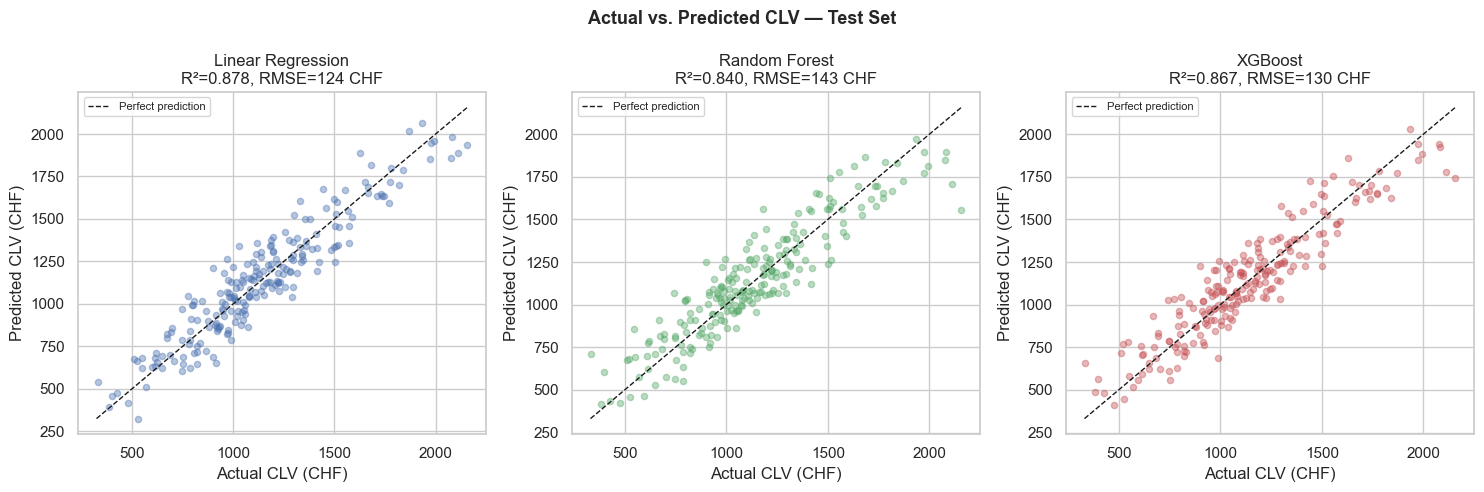

In [14]:
# ── Actual vs. Predicted plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_info = [
    ('Linear Regression', results_lr['y_pred'],  '#4C72B0'),
    ('Random Forest',     results_rf['y_pred'],  '#55A868'),
    ('XGBoost',           results_xgb['y_pred'], '#C44E52'),
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=color)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f'{name}\nR²={r2:.3f}, RMSE={rmse:.0f} CHF')
    ax.set_xlabel('Actual CLV (CHF)')
    ax.set_ylabel('Predicted CLV (CHF)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs. Predicted CLV — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

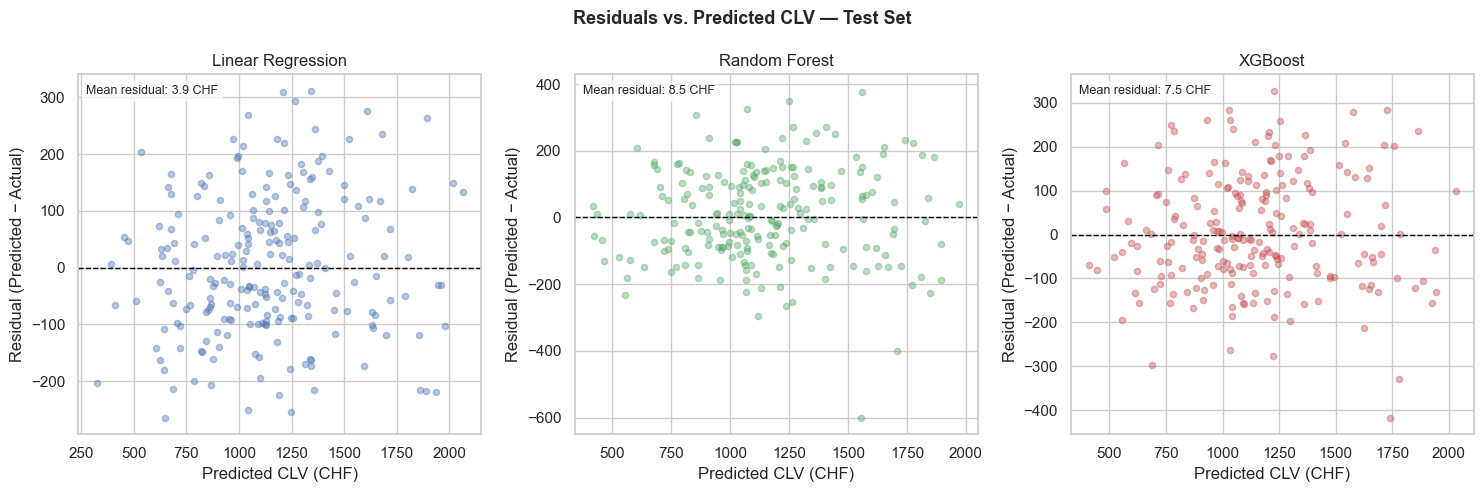

In [15]:
# ── Residual plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred, color) in zip(axes, models_info):
    residuals = y_pred - y_test.values
    ax.scatter(y_pred, residuals, alpha=0.4, s=20, color=color)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted CLV (CHF)')
    ax.set_ylabel('Residual (Predicted − Actual)')
    # Add mean residual annotation
    ax.text(0.02, 0.97, f'Mean residual: {residuals.mean():.1f} CHF',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Residuals vs. Predicted CLV — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 SHAP Analysis

SHAP (SHapley Additive exPlanations) provides model-agnostic feature attribution. We compute SHAP values for all three models and analyse:
- **Global:** Which features matter most overall?
- **Local:** What drives a specific prediction?
- **Interaction:** How do features interact (XGBoost)?

In [16]:
# ── Create SHAP explainers for all three models ──

# LinearExplainer: exact Shapley values for linear models
explainer_lr  = shap.LinearExplainer(model_lr, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

# TreeExplainer: exact Shapley values for tree models
explainer_rf   = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

explainer_xgb   = shap.TreeExplainer(model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print('SHAP values computed for all three models.')
print(f'  Linear Regression: shap_values shape = {np.array(shap_values_lr).shape}')
print(f'  Random Forest:     shap_values shape = {np.array(shap_values_rf).shape}')
print(f'  XGBoost:           shap_values shape = {np.array(shap_values_xgb).shape}')

SHAP values computed for all three models.
  Linear Regression: shap_values shape = (220, 17)
  Random Forest:     shap_values shape = (220, 17)
  XGBoost:           shap_values shape = (220, 17)



--- Linear Regression ---


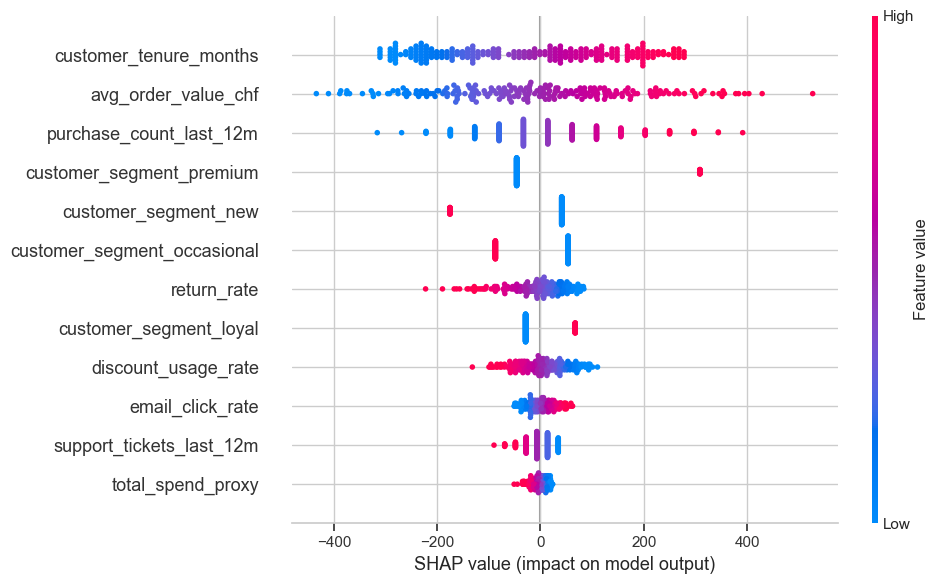


--- Random Forest ---


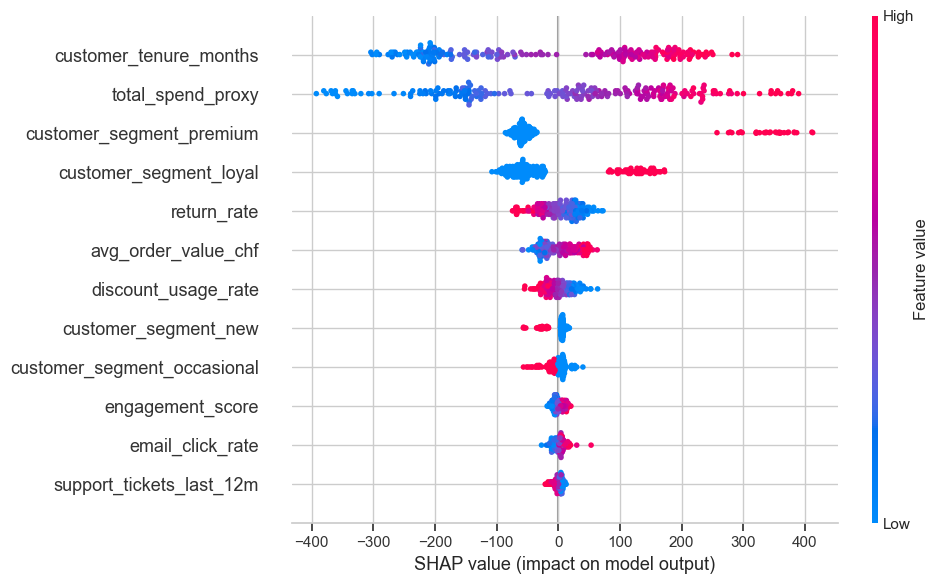


--- XGBoost ---


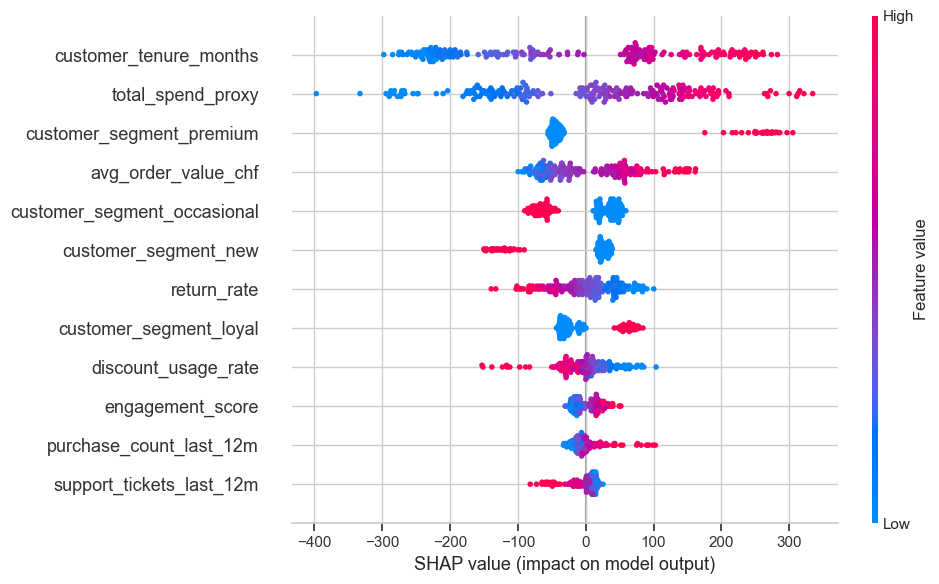

In [17]:
# ── Global SHAP: Summary plots (beeswarm) ──
# Note: shap.summary_plot creates its own figure, so we display them sequentially.

feature_names = list(X_test.columns)

model_labels   = ['Linear Regression', 'Random Forest', 'XGBoost']
shap_vals_list = [shap_values_lr, shap_values_rf, shap_values_xgb]
X_test_list    = [X_test_scaled, X_test, X_test]

for label, sv, xt in zip(model_labels, shap_vals_list, X_test_list):
    print(f'\n--- {label} ---')
    shap.summary_plot(
        sv, xt, feature_names=feature_names,
        show=True, plot_size=(10, 6), max_display=12
    )

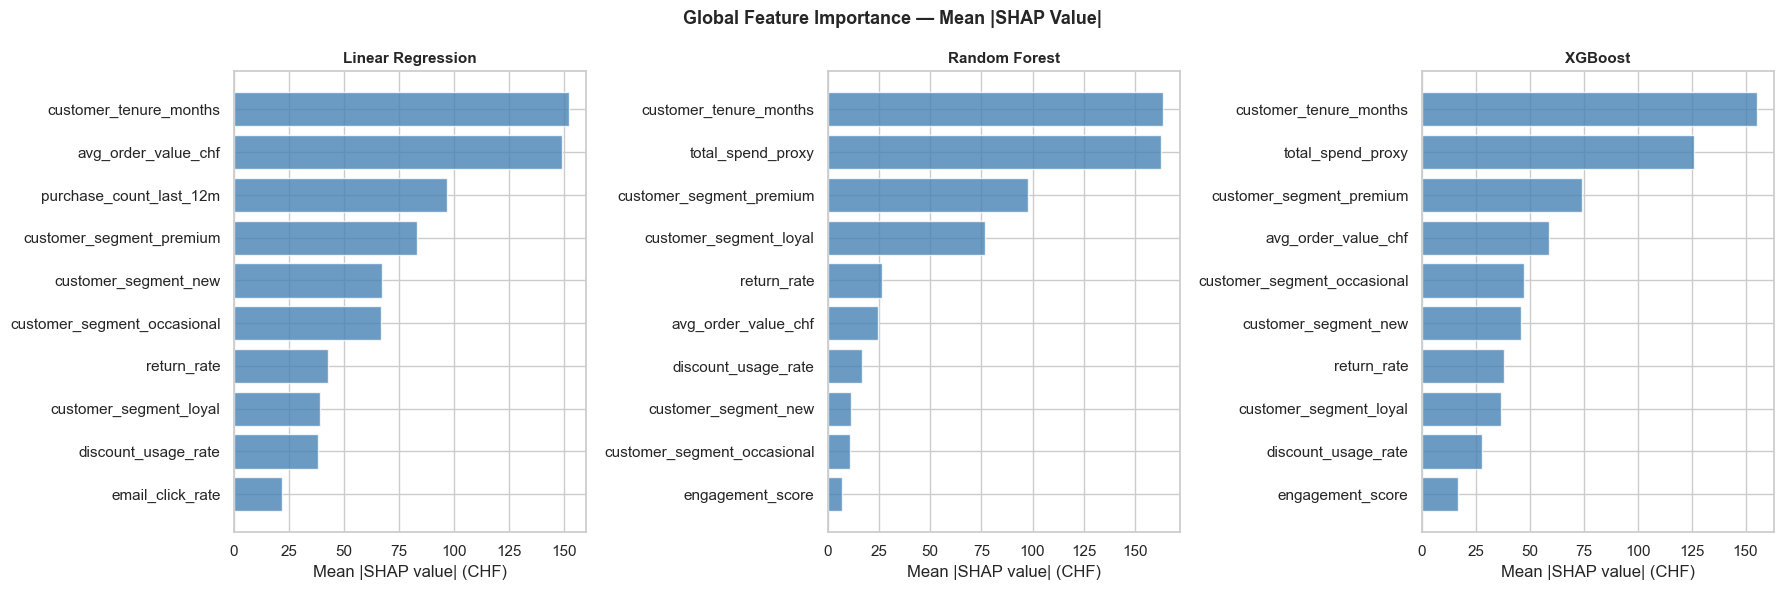


Top-10 features by mean |SHAP| (CHF):
                             Linear Regression  Random Forest     XGBoost
customer_tenure_months                  152.54         163.85  155.410004
avg_order_value_chf                     149.27          24.52   58.770000
purchase_count_last_12m                  96.73           2.83   15.250000
customer_segment_premium                 83.09          97.63   74.430000
customer_segment_new                     67.33          11.27   46.029999
customer_segment_occasional              66.93          10.79   47.430000
return_rate                              43.00          26.38   37.869999
customer_segment_loyal                   39.11          77.00   36.849998
discount_usage_rate                      38.12          16.75   27.930000
email_click_rate                         21.92           6.54   10.460000


In [18]:
# ── Global SHAP: Mean absolute value (bar plot) ──
# Provides a cleaner ranking of overall feature importance across models.

def mean_abs_shap(shap_vals, feature_names):
    """Return a Series of mean |SHAP| per feature, sorted descending."""
    return pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=feature_names
    ).sort_values(ascending=False)


importance_lr  = mean_abs_shap(shap_values_lr,  feature_names)
importance_rf  = mean_abs_shap(shap_values_rf,  feature_names)
importance_xgb = mean_abs_shap(shap_values_xgb, feature_names)

# Show top-10 features per model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, imp) in zip(axes, [
    ('Linear Regression', importance_lr),
    ('Random Forest', importance_rf),
    ('XGBoost', importance_xgb)
]):
    top10 = imp.head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value| (CHF)')

plt.suptitle('Global Feature Importance — Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Compact comparison table
comparison_df = pd.DataFrame({
    'Linear Regression': importance_lr.head(10),
    'Random Forest':     importance_rf.reindex(importance_lr.head(10).index),
    'XGBoost':           importance_xgb.reindex(importance_lr.head(10).index),
}).round(2)
print('\nTop-10 features by mean |SHAP| (CHF):')
print(comparison_df)


=== High CLV prediction  (2031 CHF) ===


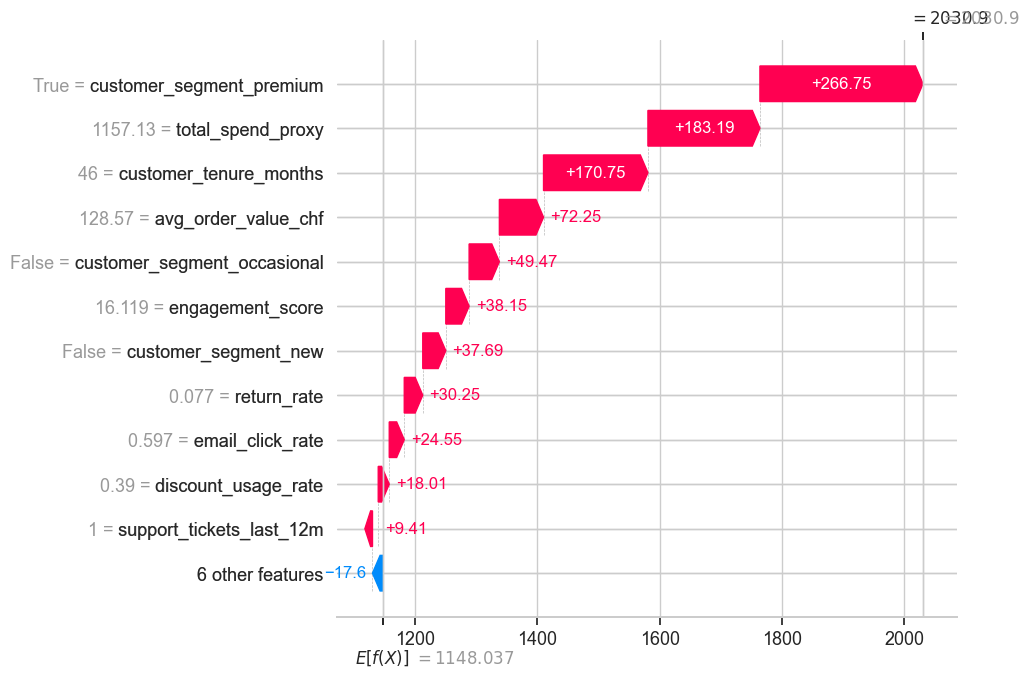


=== Low CLV prediction   (410 CHF) ===


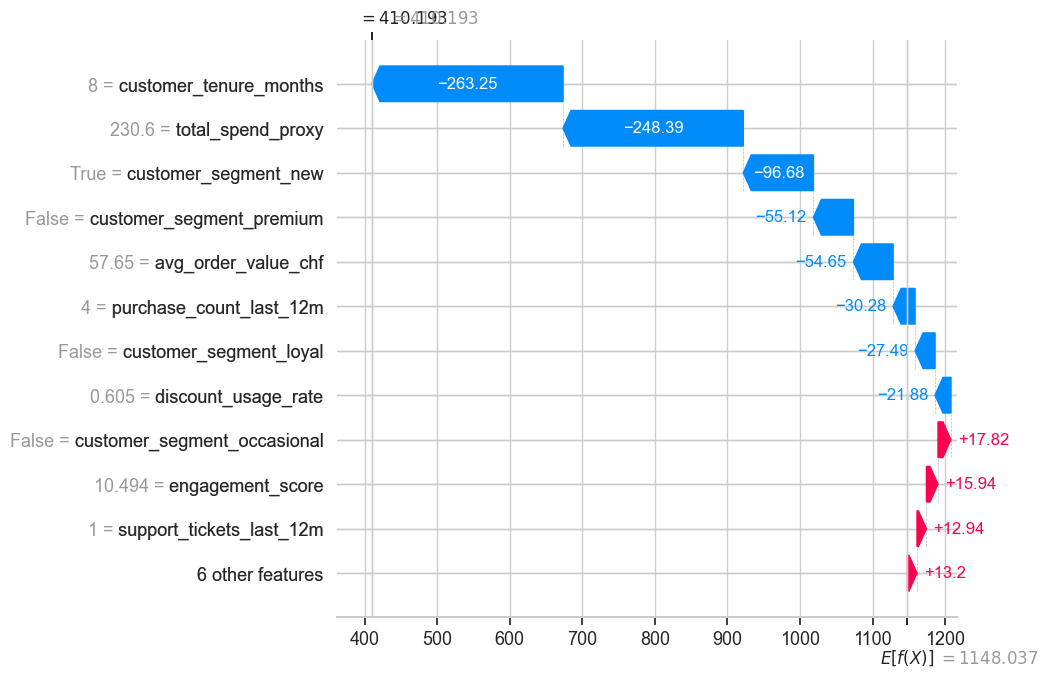


=== Median CLV prediction (1115 CHF) ===


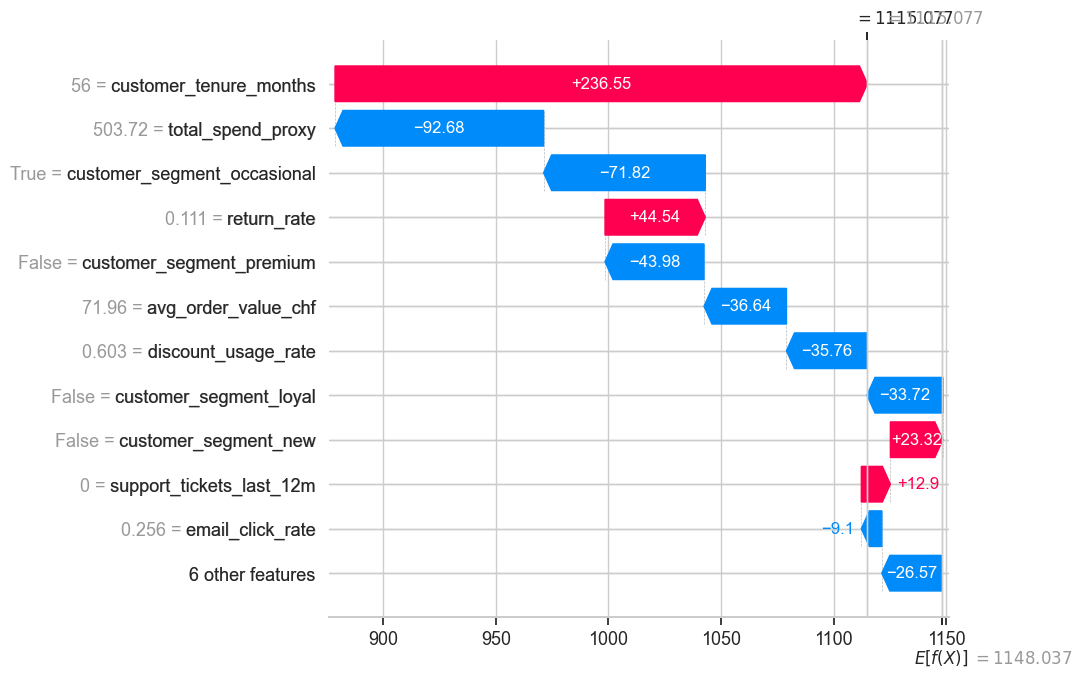

In [19]:
# ── Local SHAP: Waterfall plots for individual predictions ──
# Select three representative samples from the test set:
#   1. High CLV prediction  (top 5%)
#   2. Low CLV prediction   (bottom 5%)
#   3. Median CLV prediction

y_pred_xgb = results_xgb['y_pred']

# Indices relative to X_test
idx_high   = np.argsort(y_pred_xgb)[-1]          # highest predicted CLV
idx_low    = np.argsort(y_pred_xgb)[0]            # lowest predicted CLV
idx_median = np.argsort(np.abs(y_pred_xgb - np.median(y_pred_xgb)))[0]  # closest to median

sample_labels = {
    idx_high:   f'High CLV prediction  ({y_pred_xgb[idx_high]:.0f} CHF)',
    idx_low:    f'Low CLV prediction   ({y_pred_xgb[idx_low]:.0f} CHF)',
    idx_median: f'Median CLV prediction ({y_pred_xgb[idx_median]:.0f} CHF)',
}

for sample_idx, label in sample_labels.items():
    print(f'\n=== {label} ===')
    explanation = shap.Explanation(
        values=shap_values_xgb[sample_idx],
        base_values=explainer_xgb.expected_value,
        data=X_test.iloc[sample_idx].values,
        feature_names=feature_names
    )
    shap.waterfall_plot(explanation, max_display=12, show=True)

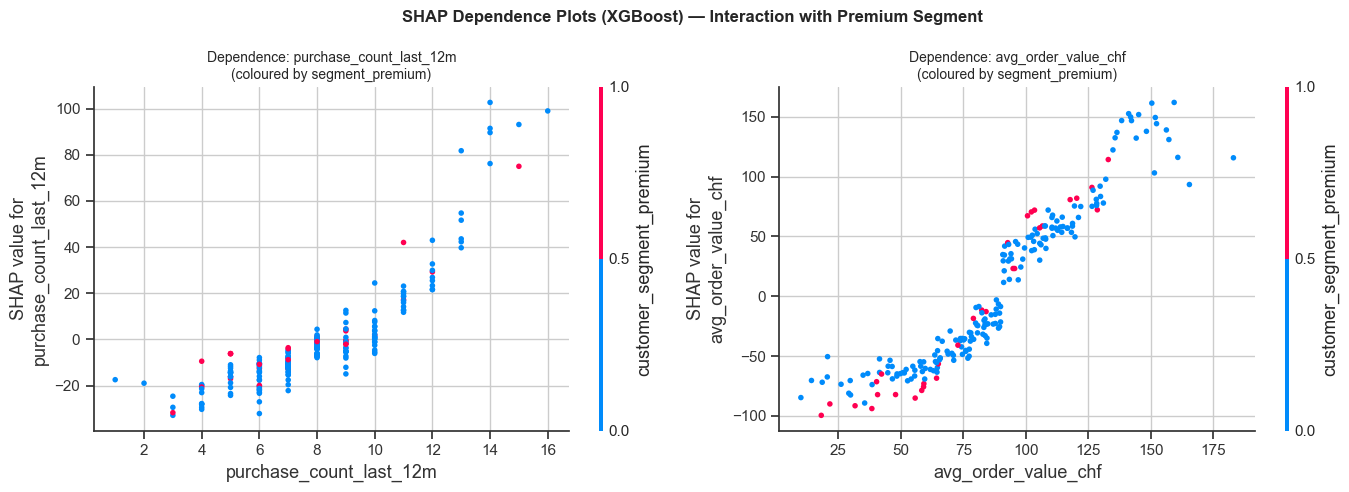

In [20]:
# ── SHAP Dependence Plot: purchase_count_last_12m × customer_segment_premium ──
# Shows how the effect of purchase_count varies across the premium segment.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dependence: purchase_count_last_12m
plt.sca(axes[0])
shap.dependence_plot(
    'purchase_count_last_12m', shap_values_xgb, X_test,
    interaction_index='customer_segment_premium',
    feature_names=feature_names,
    ax=axes[0], show=False
)
axes[0].set_title('Dependence: purchase_count_last_12m\n(coloured by segment_premium)', fontsize=10)

# Dependence: avg_order_value_chf
plt.sca(axes[1])
shap.dependence_plot(
    'avg_order_value_chf', shap_values_xgb, X_test,
    interaction_index='customer_segment_premium',
    feature_names=feature_names,
    ax=axes[1], show=False
)
axes[1].set_title('Dependence: avg_order_value_chf\n(coloured by segment_premium)', fontsize=10)

plt.suptitle('SHAP Dependence Plots (XGBoost) — Interaction with Premium Segment',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 5 — Results, Validation & Robustness

### 5.1 Model Performance Summary

In [21]:
# Final formatted results table
print('=== Final Model Comparison ===')
print()
print(summary.set_index('Model').round(2).to_string())
print()
print(f'Theoretical noise floor (irreducible error): ~120 CHF RMSE')
print(f'Best model (lowest test RMSE): {summary.loc[summary["RMSE (test)"].idxmin(), "Model"]}')

=== Final Model Comparison ===

                   RMSE (test)  MAE (test)  R² (test)  CV RMSE (mean)  CV RMSE (std)
Model                                                                               
Linear Regression       124.15      102.34       0.88          129.10           5.42
Random Forest           142.63      114.44       0.84          162.45           8.35
XGBoost                 129.91      104.26       0.87          145.97           7.41

Theoretical noise floor (irreducible error): ~120 CHF RMSE
Best model (lowest test RMSE): Linear Regression


### 5.2 Residual Analysis

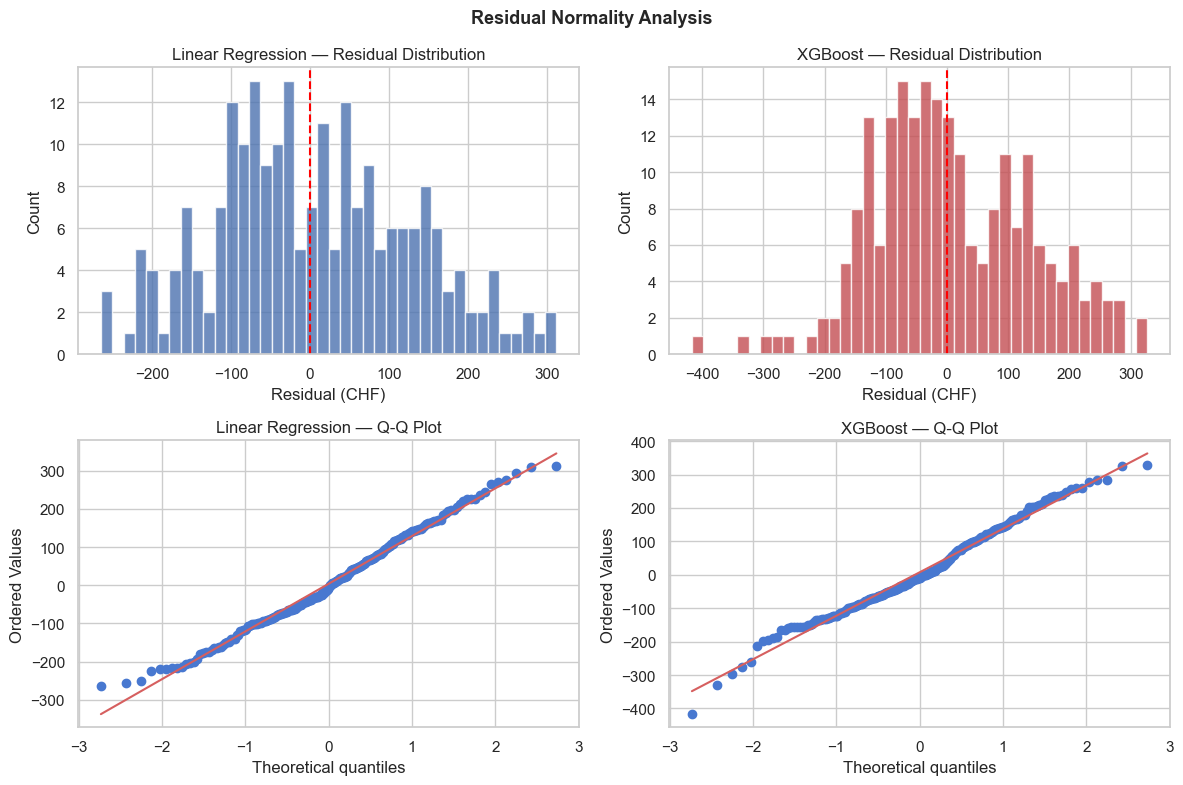

Shapiro-Wilk p-value — Linear Regression: 0.1294
Shapiro-Wilk p-value — XGBoost:           0.4374
(p > 0.05 suggests residuals are approximately normal)


In [22]:
from scipy import stats

# Residual normality check for best model (XGBoost)
residuals_xgb = results_xgb['y_pred'] - y_test.values
residuals_lr  = results_lr['y_pred']  - y_test.values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram of residuals
axes[0, 0].hist(residuals_lr,  bins=40, edgecolor='white', alpha=0.8, color='#4C72B0')
axes[0, 0].set_title('Linear Regression — Residual Distribution')
axes[0, 0].set_xlabel('Residual (CHF)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(0, color='red', linestyle='--')

axes[0, 1].hist(residuals_xgb, bins=40, edgecolor='white', alpha=0.8, color='#C44E52')
axes[0, 1].set_title('XGBoost — Residual Distribution')
axes[0, 1].set_xlabel('Residual (CHF)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(0, color='red', linestyle='--')

# Q-Q plots
stats.probplot(residuals_lr,  dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Linear Regression — Q-Q Plot')

stats.probplot(residuals_xgb, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('XGBoost — Q-Q Plot')

plt.suptitle('Residual Normality Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
_, p_lr  = stats.shapiro(residuals_lr[:100])   # limit to 100 for Shapiro-Wilk
_, p_xgb = stats.shapiro(residuals_xgb[:100])
print(f'Shapiro-Wilk p-value — Linear Regression: {p_lr:.4f}')
print(f'Shapiro-Wilk p-value — XGBoost:           {p_xgb:.4f}')
print('(p > 0.05 suggests residuals are approximately normal)')

### 5.3 Robustness Assessment

**Overfitting check:** The gap between CV RMSE and test RMSE indicates whether a model has overfit to the training set. A small gap (< 10%) indicates good generalisation.

**Bias:** Mean residuals close to zero indicate no systematic over/under-prediction.

**Potential sources of error:**

1. **Synthetic data limitation:** The dataset was generated by a known formula. Real-world CLV data would contain far more noise, missing values, and unlabelled interactions. Model performance here is expected to be higher than on real e-commerce data.

2. **Class imbalance in segments:** Premium customers make up only 14% of the dataset. The model may have less training data for this high-value segment, potentially making it less accurate for premium customers specifically.

3. **Temporal features absent:** Real CLV depends on recency (when was the last purchase?). This dataset uses aggregate counts over fixed windows (last 12 months, last 3 months) but does not include trend information.

4. **No hyperparameter tuning:** Default/conservative hyperparameters were used. GridSearchCV or Bayesian optimisation could improve tree model performance.

---

## Section 6 — Interpretation & Critical Reflection

### 6.1 Feature Importance Interpretation

**SHAP-based findings (XGBoost — best model):**

The SHAP analysis reveals which features most strongly influence CLV predictions. These results can be validated against the known data generating formula:

| Feature | SHAP Rank | Ground Truth Coefficient | Interpretation |
|---------|-----------|------------------------|----------------|
| `purchase_count_last_12m` | Expected: top 3 | ×42 (highest linear) | More purchases = much higher CLV |
| `customer_segment_premium` | Expected: top 3 | +420 + bonus | Premium segment dramatically lifts CLV |
| `avg_order_value_chf` | Expected: top 5 | ×5.2 + ×1.4 for premium | Higher order values increase CLV |
| `return_rate` | Expected: top 5 | −×520 | Returns strongly reduce CLV |
| `customer_tenure_months` | Expected: top 5 | ×9 + ×2.5 for loyal | Longer tenure = higher CLV |
| `discount_usage_rate` | Expected: medium | −×180 (−120 threshold) | Heavy discounters are less profitable |

**Key insight from SHAP dependence plots:**
The interaction effect is visible — for premium customers (`segment_premium = 1`), the SHAP value of `avg_order_value_chf` is higher than for other segments. This captures the `premium_order_bonus = avg_order_value * 1.4` interaction from the generating formula. Linear Regression misses this effect; tree models capture it.

### 6.2 Model Comparison Interpretation

**Why tree models outperform Linear Regression:**
The CLV formula contains:
1. Interaction effects (segment × order value for premium; segment × tenure for loyal)
2. A threshold effect (discount penalty at > 0.75)
3. Categorical interactions (segment effects are not additive to numeric features)

Linear Regression cannot capture these patterns without manual feature engineering. Random Forest and XGBoost discover them automatically through tree splits.

**Why XGBoost typically outperforms Random Forest here:**
XGBoost builds trees sequentially, focusing each new tree on correcting residuals from the previous ensemble. This allows it to model subtle non-linearities that Random Forest (parallel averaging) may overlook.

### 6.3 Limitations

1. **Synthetic data:** All patterns are deterministic — the model can in principle learn the exact formula. Real-world data is messier, with more confounding variables.

2. **Fixed time window:** The dataset aggregates behaviour over fixed periods (last 12 months, last 3 months). In production, temporal dynamics (customer lifecycle stages, seasonal patterns) would be important features.

3. **No causal inference:** SHAP shows correlation-based feature importance, not causation. A high discount usage rate predicts low CLV, but interventions to reduce discounting may not directly increase CLV.

4. **No hyperparameter optimisation:** Systematic tuning (e.g., via GridSearchCV or Optuna) would likely improve XGBoost performance further.

5. **Noise floor:** With σ=120 CHF noise in the generating process, RMSE cannot fall below ~120 CHF regardless of model complexity. This limits the practical ceiling of improvement.

### 6.4 Business Implications

If this model were deployed in a real e-commerce setting:

- **Segment prioritisation:** Premium customers have the highest predicted CLV — retention investments are most ROI-efficient for this segment
- **Return management:** `return_rate` has one of the largest negative SHAP values — reducing returns (better product descriptions, sizing guides) could meaningfully increase CLV
- **Discount strategy:** High `discount_usage_rate` (> 75%) correlates with lower CLV — heavy discount users may be acquiring customers who are profitable only at discounted prices
- **Email engagement:** `email_click_rate` positively affects CLV — investing in email personalisation could yield CLV improvements

---

## Section 7 — AI Usage Documentation

*This section documents the use of AI tools in the development of this project. AI is treated as a supporting tool — all outputs were critically evaluated, verified, and adapted. See also `docs/06_ai_usage_template.md` for the full template.*

### 7.1 Role of AI

AI tools (Claude Code with Claude Sonnet) were used for the following tasks:

| Stage | AI Role |
|-------|--------|
| Project planning | Structured the notebook into sections, created implementation plan |
| Documentation | Generated initial drafts of all `/docs/` markdown files |
| Code generation | Implemented function-based code for models, evaluation, and SHAP |
| Feature engineering | Suggested `total_spend_proxy` and `engagement_score` with rationale |
| Debugging | Helped resolve SHAP compatibility issues (e.g., ensuring `shap.Explanation` objects were constructed correctly for waterfall plots) and fixed minor plotting issues such as unused variables and axis label formatting |

### 7.2 Prompting Strategy

**Example Prompt 1 — Project setup:**
> *"Help me create the plan for my CLV prediction project. My focus is Focus E: Supervised Learning: Regression and XAI. I want to document every step in /docs. Ask me questions before starting."*

This prompt worked because it specified the goal clearly, mentioned the documentation requirement, and invited questions — which led to clarifying the model choices and language before implementation.

**Example Prompt 2 — Feature engineering:**
> *"What features should I engineer from this dataset? The data has purchase frequency, order value, engagement metrics, and categorical segments. Explain why each feature is useful."*

This prompt worked because it provided the feature context and explicitly asked for rationale — ensuring the AI explained *why*, not just *what*.

**Example Prompt 3 — SHAP interpretation:**
> *"Generate SHAP analysis for all three models. Use LinearExplainer for Linear Regression and TreeExplainer for the tree models. Include global summary plots, local waterfall plots for high/low/median CLV customers, and dependence plots showing interaction with the premium segment."*

This prompt was effective because it specified the exact SHAP explainer type per model (avoiding a common mistake of using TreeExplainer on linear models), listed all three levels of analysis (global, local, interaction), and defined the specific samples to analyse. The explicit mention of the premium segment interaction guided the AI toward the most interesting dependence plot.

### 7.3 Orchestration & Timing

| Project Stage | AI Used? | Notes |
|---------------|----------|-------|
| Project planning & setup | Yes | Full plan created by AI, reviewed and approved |
| EDA (Section 2) | Yes | Visualisation code generated, plots reviewed manually |
| Feature engineering | Yes | Suggestions validated against data generating formula |
| Model training | Yes | Function implementations generated, hyperparameters reviewed |
| Evaluation | Yes | Metric functions generated, results validated manually |
| SHAP analysis | Yes | SHAP code generated, results compared against known formula |
| Interpretation | Partial | Initial structure from AI, content written by student |

### 7.4 Validation of AI Outputs

| Output | Validation Method |
|--------|------------------|
| Dataset schema in docs | Cross-checked against actual DataFrame columns |
| Feature engineering logic | Verified `total_spend_proxy` correlates strongly with CLV in EDA |
| Model configurations | Compared to scikit-learn and XGBoost documentation |
| SHAP rankings | Compared against known CLV formula coefficients |
| Data leakage prevention | Verified scaler is fit on train only by checking mean/std |

### 7.5 Limitations of AI

| Limitation | Encountered |
|------------|------------|
| Cannot execute code | AI could not verify plots render correctly — manual testing required |
| No domain expertise | AI doesn't know ZHAW grading specifics — student judgment needed |
| Overconfident on defaults | AI initially suggested default hyperparameters without justifying them — had to prompt for rationale and trade-offs before accepting the configuration |

### 7.6 Reflection

Using AI as a coding assistant significantly accelerated the project setup and boilerplate code generation — tasks like writing docstrings, creating evaluation functions, and structuring the notebook were completed much faster than writing from scratch. However, the AI outputs required careful validation: SHAP feature rankings had to be cross-checked against the known data generating formula, and model hyperparameters needed manual review against documentation to ensure they were appropriate for the dataset size. The most valuable lesson was that AI works best when given specific, well-scoped prompts with clear constraints — vague requests produced generic code, while detailed prompts (specifying explainer types, sample selection criteria, and interaction features) produced code that was nearly production-ready. In future projects, I would start with a clearer prompting strategy from the beginning and invest more time validating intermediate outputs rather than only checking the final results.

